In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
df = pd.read_csv('winequality-white.csv', sep=';')
X = df.drop(columns=['quality'])
y = df['quality']

In [2]:
#Zadanie 1
scaler_task1 = StandardScaler()
X_scaled_task1 = scaler_task1.fit_transform(X)
n_features = X.shape[1]
pca_task1 = PCA(n_components=n_features - 2)
X_pca_task1 = pca_task1.fit_transform(X_scaled_task1)
explained_variance_ratio = np.sum(pca_task1.explained_variance_ratio_)
print(f"Nowy zbiór wyjaśnia {explained_variance_ratio:.2%} wariancji oryginalnego zbioru.")

Zadanie 1: Nowy zbiór wyjaśnia 97.18% wariancji oryginalnego zbioru.


In [3]:
#Zadanie 2
pca_task2 = PCA(n_components=0.95)
X_pca_task2 = pca_task2.fit_transform(X_scaled_task1)
print(f"Aby zachować 95% wariancji, pozostawiono {pca_task2.n_components_} cech.")

Zadanie 2: Aby zachować 95% wariancji, pozostawiono 9 cech.


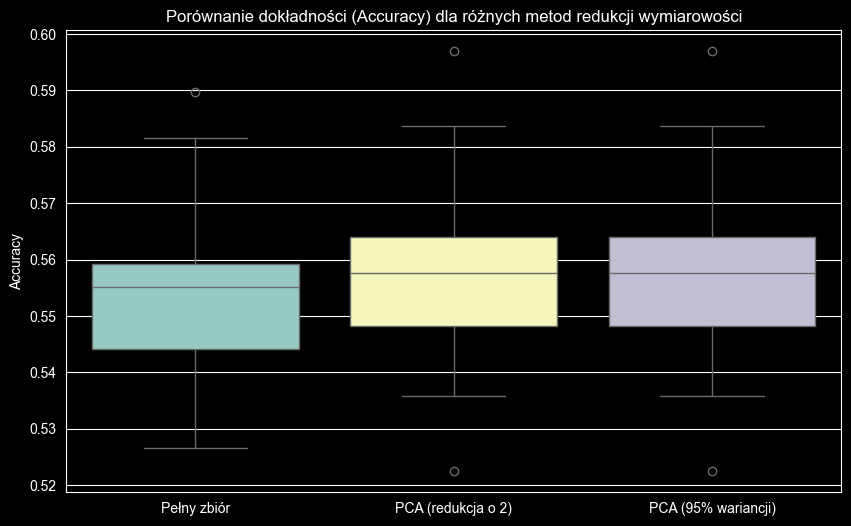

Średnie wyniki dokładności:
Pełny zbiór            0.553061
PCA (redukcja o 2)     0.558231
PCA (95% wariancji)    0.558231
dtype: float64


In [5]:
#Zadanie 3
def run_experiments(X, y, n_runs=10):
    results = {
        'Pełny zbiór': [],
        'PCA (redukcja o 2)': [],
        'PCA (95% wariancji)': []
    }
    for i in range(n_runs):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        knn_full = KNeighborsClassifier()
        knn_full.fit(X_train_scaled, y_train)
        results['Pełny zbiór'].append(accuracy_score(y_test, knn_full.predict(X_test_scaled)))
        pca_1 = PCA(n_components=X.shape[1] - 2)
        X_train_pca1 = pca_1.fit_transform(X_train_scaled)
        X_test_pca1 = pca_1.transform(X_test_scaled)
        knn_pca1 = KNeighborsClassifier()
        knn_pca1.fit(X_train_pca1, y_train)
        results['PCA (redukcja o 2)'].append(accuracy_score(y_test, knn_pca1.predict(X_test_pca1)))
        pca_2 = PCA(n_components=0.95)
        X_train_pca2 = pca_2.fit_transform(X_train_scaled)
        X_test_pca2 = pca_2.transform(X_test_scaled)
        knn_pca2 = KNeighborsClassifier()
        knn_pca2.fit(X_train_pca2, y_train)
        results['PCA (95% wariancji)'].append(accuracy_score(y_test, knn_pca2.predict(X_test_pca2)))
    return pd.DataFrame(results)
exp_results = run_experiments(X, y, n_runs=30)
plt.figure(figsize=(10, 6))
sns.boxplot(data=exp_results)
plt.title('Porównanie dokładności (Accuracy) dla różnych metod redukcji wymiarowości')
plt.ylabel('Accuracy')
plt.show()
print("Średnie wyniki dokładności:")
print(exp_results.mean())